In [1]:
from pathlib import Path
from torchvision import transforms
from PIL import Image

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import librosa

In [2]:
def plot_spectrogram(specgram, title=None, ylabel="Frequency bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)

    # Title
    if title:
        ax.set_title(title)

    # Spectrogram (power -> dB)
    img = ax.imshow(
        librosa.power_to_db(specgram, ref=np.max),
        origin="lower",
        aspect="auto",
        interpolation="nearest"
    )

    # Labels
    ax.set_xlabel("Time frame")
    ax.set_ylabel(ylabel)

    # Colorbar (important, not decorative)
    plt.colorbar(img, ax=ax, label="Power (dB)")


In [29]:
def show_waveform(filepath: Path, label: str, ax = None, figsize: tuple[int] = (10, 3), target_len: int = 4928):
    """Shows raw waveform of audio"""
    waveform, fs = torchaudio.load(filepath)
    waveform = waveform.squeeze(0)

    T = waveform.shape[0]
    if T > target_len:
        waveform = waveform[:target_len]
    else:
        waveform = F.pad(waveform, (0, target_len - T))

    if ax is None:
        plt.figure(figsize=figsize)
        plt.plot(waveform.numpy(), linewidth=0.8)
        plt.title(f"Raw waveform | label={label} | fs={fs}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()
    else:
        ax.plot(waveform.numpy(), linewidth=0.8)
        ax.set_title(f"Raw waveform | label={label} | fs={fs}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Amplitude")

In [31]:
def show_fft(filepath: Path, label: str, ax = None, f_max: int = 0, figsize: tuple[int] = (10, 3)):
    """Shows FFT of the audio"""
    waveform, fs = torchaudio.load(filepath)
    signal = waveform.squeeze(0).numpy()
    
    fft = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), 1 / fs)

    mag = np.abs(fft)
    mag /= mag.max()  # normalize 0–1

    if f_max > 0:
        mask = freqs <= f_max
        freqs = freqs[mask]
        mag = mag[mask]

    if ax is None:
        plt.figure(figsize=figsize)
        plt.plot(freqs, mag)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude (normalized)")
        plt.ylim(0, 1.0)
        plt.title(f"FFT: {label}")
        plt.tight_layout()
        plt.show()
    else:
        ax.plot(freqs, mag)
        ax.set_title(f"FFT: {label}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Magnitude (normalized)")


In [36]:
def to_melspec(filepath: Path, ax = None, n_fft: int = 1024, win_length: int = None, hop_length: int = 128, n_mels: int = 256):
    """Processes the audio to mel spectrogram""" 
    sample, fs = torchaudio.load(filepath)
    mel_spectrogram = T.MelSpectrogram(
        sample_rate=fs,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        center=True,
        pad_mode="reflect",
        power=2.0,
        norm="slaney",
        n_mels=n_mels,
        mel_scale="htk",
    )

    melspec = mel_spectrogram(sample)
    plot_spectrogram(melspec[0], filepath.name, ax = ax)

In [6]:
def show_melspec(filepath: Path, label: str, figsize: tuple[int] = (4, 4)):
    """Show mel spec from dataset"""
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])
    
    image = Image.open(filepath).convert("RGB")
    image = transform(image)
    image = torch.clamp(image, 0, 1)

    plt.figure(figsize=figsize)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Mel Spectrogram | label={label}")
    plt.tight_layout()
    plt.show()

In [60]:
def show_spec(filepath: Path, label: str, ax = None, figsize: tuple[int] = (10, 3), n_fft: int = 1024, hop_length: int = 64):
    """Show spectrogram of audio"""
    sample, fs = torchaudio.load(filepath)
    spectrogram = T.Spectrogram(n_fft=n_fft, hop_length=hop_length)
    spec = spectrogram(sample)
    plot_spectrogram(spec[0], filepath.name, ax = ax)

In [54]:
rootdir = Path(os.getcwd()).parent
datadir = Path(rootdir, "data", "audio")
specdir = Path(datadir, "spec")
rawdir = Path(datadir, "recordings")

In [9]:
# Get all samples' path
spec_list = [x for x in specdir.glob("*.png")]
rec_list = [x for x in rawdir.glob("*.wav")]
print(len(spec_list), len(rec_list))

3000 3000


In [10]:
spec_list[0].__str__()

'/home/zheri/Projects/signal-processing-demo/data/audio/spec/5_lucas_22.png'

In [11]:
sample_idx = 1

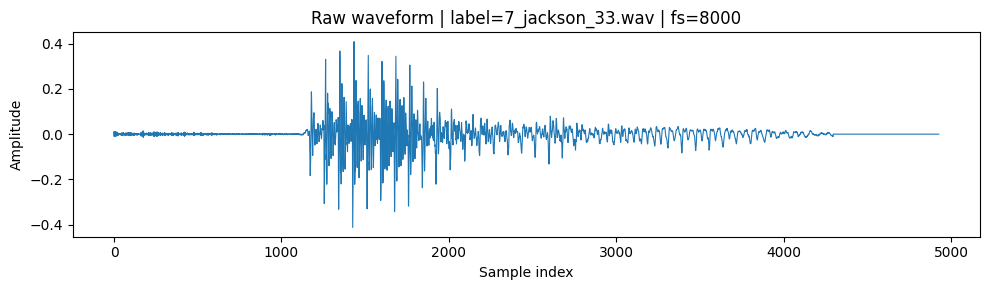

In [22]:
# Show raw recording example
show_waveform(rec_list[sample_idx], rec_list[sample_idx].name)

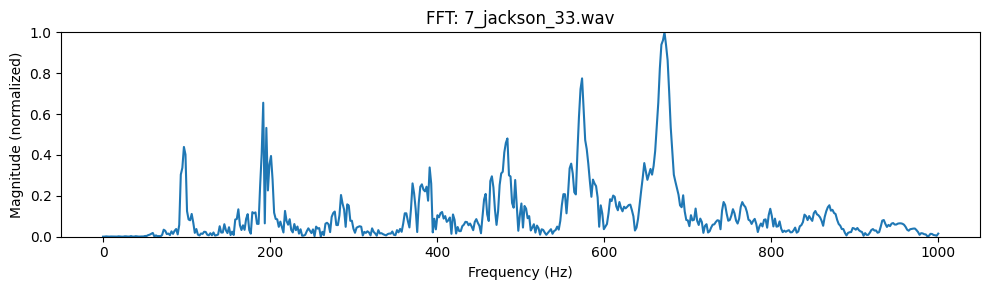

In [32]:
# Show fft of recording example
show_fft(rec_list[sample_idx], rec_list[sample_idx].name, f_max = 1000)

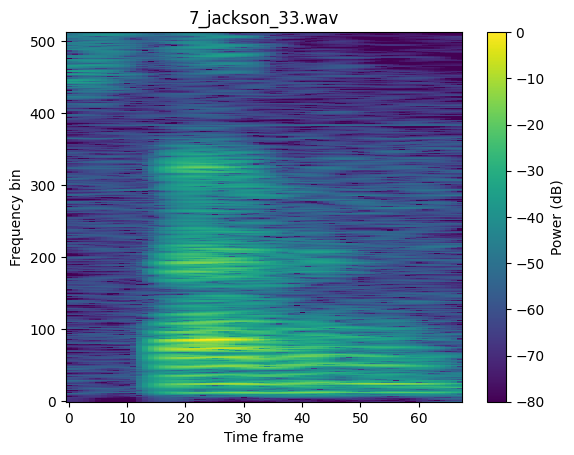

In [14]:
show_spec(rec_list[sample_idx], rec_list[sample_idx].name, n_fft = 1024)

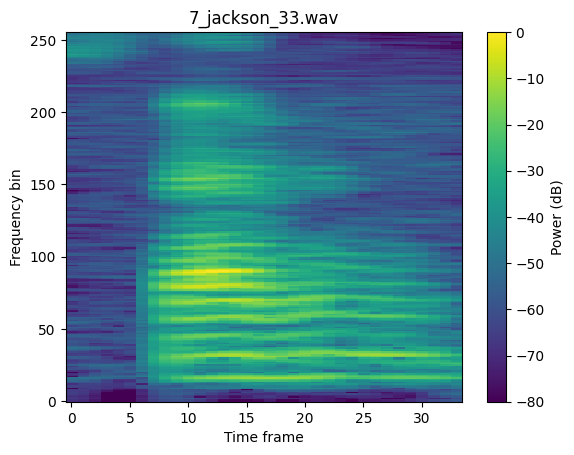

In [19]:
# Process raw sample to mel spec
to_melspec(rec_list[sample_idx])

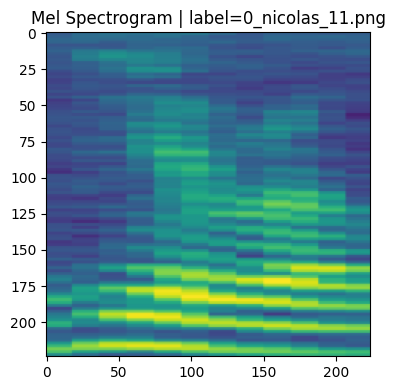

In [16]:
# Show mel spec example from dataset
show_melspec(spec_list[sample_idx], spec_list[sample_idx].name)

-----

In [20]:
### show examples
rng = np.random.default_rng()

num_samples = 3
idx = [rng.integers(low = 0, high = len(rec_list)) for x in range(num_samples)]
idx

[np.int64(2), np.int64(1956), np.int64(1010)]

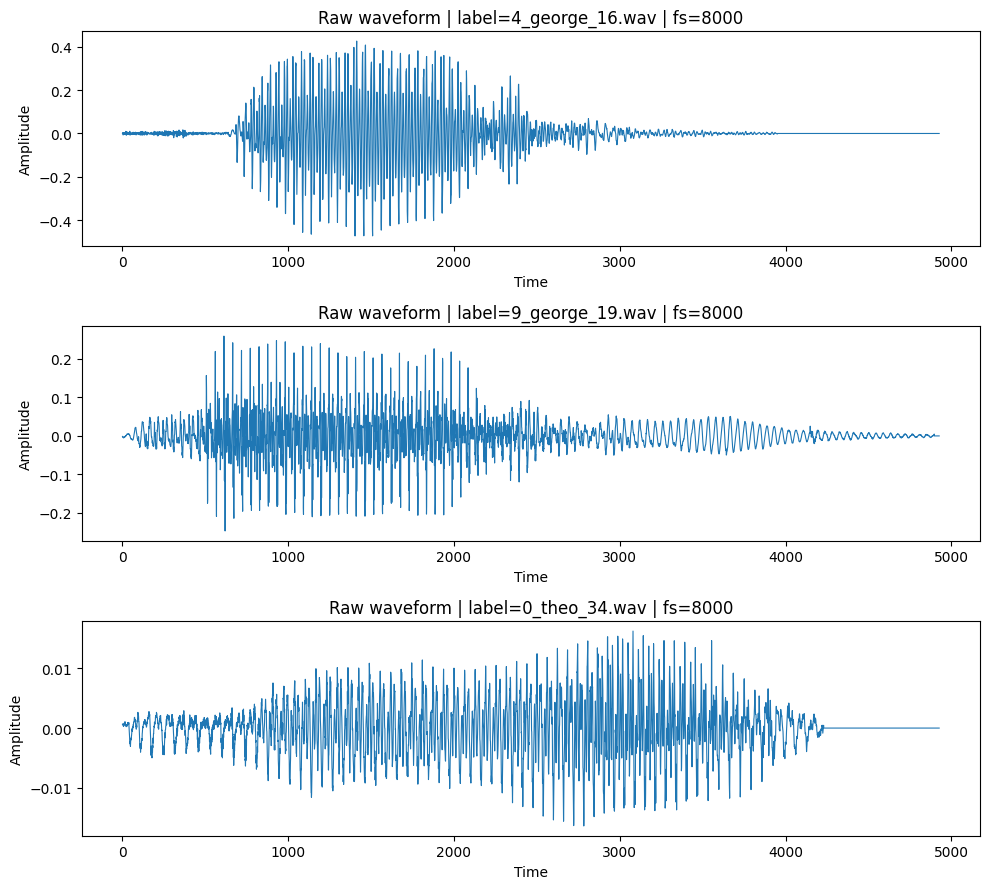

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
for i in range(num_samples):
    sample = rec_list[idx[i]]
    show_waveform(
        sample,
        sample.name,
        ax = axes[i]
    )

plt.tight_layout()
plt.show()

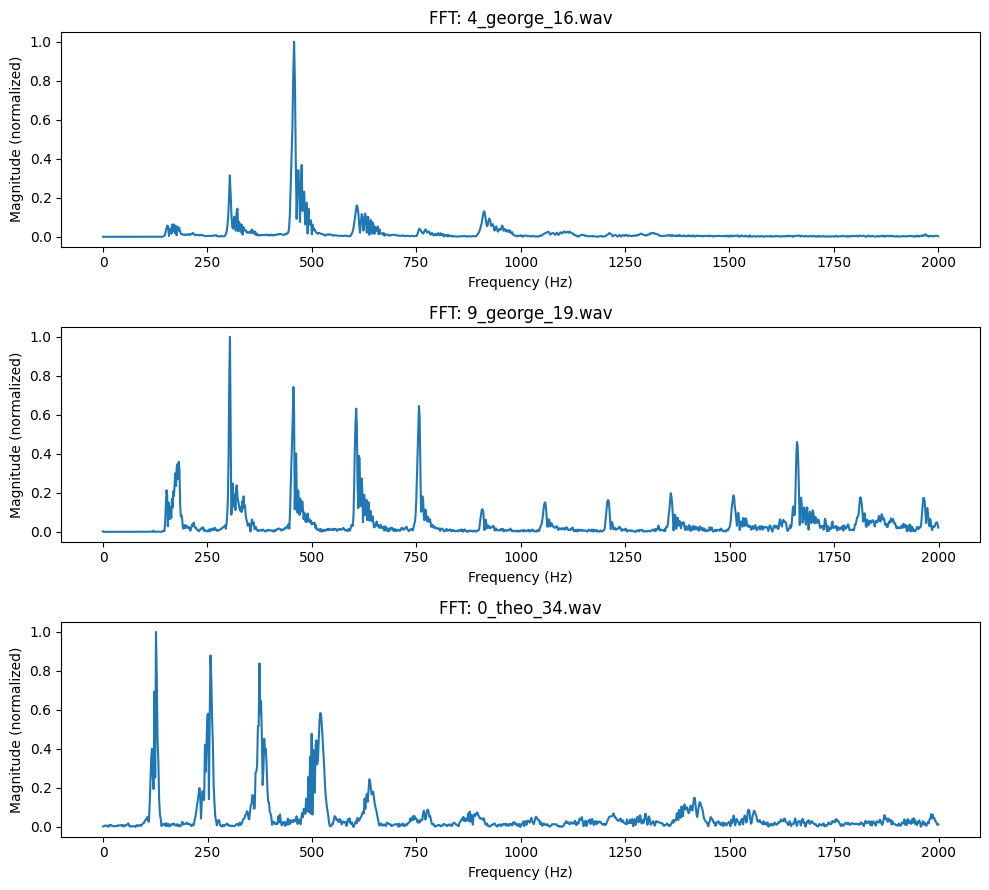

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
for i in range(num_samples):
    sample = rec_list[idx[i]]
    show_fft(
        sample,
        sample.name,
        ax = axes[i],
        f_max = 2000
    )

plt.tight_layout()
plt.show()

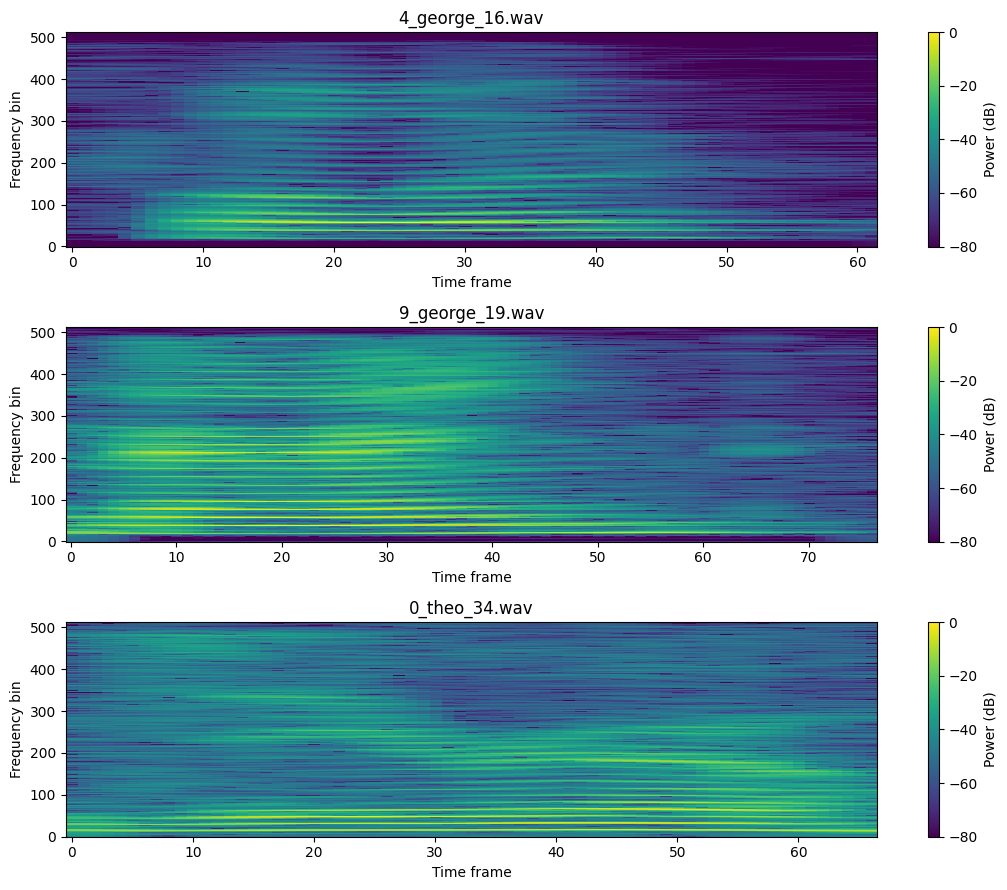

In [68]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
for i in range(num_samples):
    sample = rec_list[idx[i]]
    show_spec(
        sample,
        sample.name,
        ax = axes[i]
    )

plt.tight_layout()
plt.show()

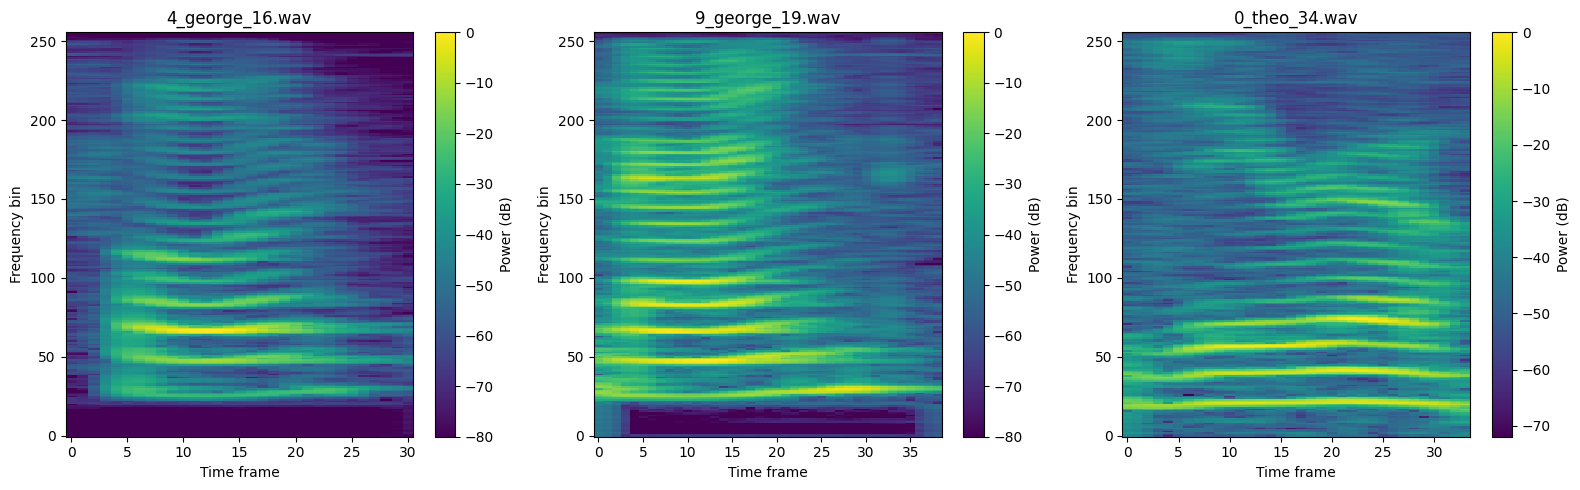

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i in range(num_samples):
    sample = rec_list[idx[i]]
    to_melspec(
        sample,
        ax = axes[i]
    )

plt.tight_layout()
plt.show()

```python
import torch
import torchaudio
import torchvision
```